# mask + prepare images for AutoProf + run Autoprof

> Mask sources in a Euclid image prior to ICL measurement.

> Prepare NaN values cleaned images for autoprof

> Run Autoprof on image, using the measurement mask from step one. 

In [1]:
# | default_exp euclid.mask

In [2]:
# | exporti
import pandas as pd 

import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
from astropy.nddata import CCDData

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)
from nicl.utilities import (
    calc_sb_threshold as _calc_sb_threshold,
    get_pixel_scale,
    sb_to_adu,
)

In [3]:
# | hide

import logging

import matplotlib.pyplot as plt


from nicl.main import configure_logging
from nicl.mask import plot_mask

import importlib.util
import sys
import os
import traceback
from textwrap import dedent

import autoprof
from autoprof import Pipeline 

from photutils.aperture import EllipticalAnnulus, CircularAnnulus
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.stats import median_abs_deviation

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

In [4]:
# | exporti
plt.style.use("nicl.euclid.v1nicl")

### masking is too sensitive to NSIGMA in icl mask


In [5]:
######### Parameters below are being called in create_masks
ICL_NSIGMA = 0.5    
ICL_SMOOTH_SIGMA = 50.0
ICL_BKG_BOX_SIZE = 300
ICL_BKG_FILTER_SIZE = 3
ICL_DILATION_RADIUS = 70.0
ICL_MEDIAN_FILTER = True
REGULAR_DETECTION_PARAMS = {
    "nsigma": 3.0,
    "background": 0.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 32,
    "contrast": 0.01,
    "bkg_box_size": 200,
    "bkg_filter_size": 3,
}
REGULAR_GROWTH = 0.5
FAINT_DETECTION_PARAMS = {
    "nsigma": 2.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 128,
    "contrast": 0.001,
}
FAINT_GROWTH = 0.25
FAINT_BKG_SIGMA = 50.0
NIR_STACK_BKG_BOX_SIZE = 300
NIR_STACK_BKG_FILTER_SIZE = 3

In [6]:

def calc_sb_threshold(
    z,  # cluster redshift
    filter,  # Euclid filter: VIS, Y, J or H
):
    """Determine the ICL surface brightness threshold for a given redshift and Euclid filter."""
    filter = filter.replace("NIR_", "")
    filter = f"Euclid-{filter}.ecsv"
    return _calc_sb_threshold(z, filter)
    
def create_masks(
    image,  # the image to mask, with bad pixels set to NaN, as a CCDImage or filename
    *,  # the following parameters must be provided as keyword arguments if required
    z=None,  # the cluster redshift for the BCG mask; if None then returned BCG mask is None
    filter=None,  # the filter name for the BCG mask; if None then returned BCG mask is None
    centre_pos=None,  # the position of the BCG/cluster centre; set to False for a non-cluster image
    make_faint_mask=True,  # whether to create a separate object mask in the ICL region
    zeropoint="ZPAB",  # the zeropoint, either as a header keyword or numeric value
):
    """Create BCG, ICL, object and faint masks with default settings for Euclid data.

    These default settings are to be refined.
    """
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")  # unit does not matter
    # === Bad pixels ===
    badpixel_mask = ~np.isfinite(image)
    # === BCG ===
    if centre_pos is not False and z is not None and filter is not None:
        sb_threshold = calc_sb_threshold(z, filter)
        if isinstance(zeropoint, str):
            zp = image.header[zeropoint] * u.ABmag
        else:
            zp = zeropoint * u.ABmag
        sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(image), zp)
        bcg_mask = create_bcg_mask(
            image.data,
            sb_threshold=sb_adu_threshold,
            centre_pos=centre_pos,
            wcs=image.wcs,
        )
    else:
        bcg_mask = None
    # === ICL ===
    if centre_pos is not False:
        icl_mask, _ = create_icl_mask(
            image.data,
            centre_pos=centre_pos,
            wcs=image.wcs,
            nsigma=ICL_NSIGMA,
            smooth_sigma=ICL_SMOOTH_SIGMA,
            bkg_box_size=ICL_BKG_BOX_SIZE,
            bkg_filter_size=ICL_BKG_FILTER_SIZE,
            dilation_radius=ICL_DILATION_RADIUS,
            median_filter=ICL_MEDIAN_FILTER,
        )
    else:
        icl_mask = None
    # === Regular objects ===
    if make_faint_mask:
        # In this case, we exclude objects under the ICL mask,
        # as these will be included in the faint mask
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_mask=icl_mask,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    else:
        # In this case, we only exclude the object at the central position
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    # === Faint objects (under ICL) ===
    if centre_pos is not False and make_faint_mask:
        faint_mask, faint_bkg, faint_threshold = create_faint_mask(
            image.data,
            include_mask=centre_mask,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=FAINT_GROWTH,
            detection_params=FAINT_DETECTION_PARAMS,
            bkg_sigma=FAINT_BKG_SIGMA,
        )
    else:
        faint_mask = None
    output_masks = {
        "badpixel": badpixel_mask,
        "bcg": bcg_mask,
        "icl": icl_mask,
        "object": object_mask,
        "faint": faint_mask,
    }
    return output_masks

# updated to include wcs information while storing masks
def save_masks(
    masks,    # Dictionary of masks returned by create_masks
    output_dir,  
    label=None,   
    reference_header=None 
):
    """Save all masks produced by create_masks to disk."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{label}_" if label else ""
    for mask_name, mask in masks.items():
        if mask is not None:
            mask = mask.astype(np.uint8)
            output_fn = output_dir / f"{prefix}{mask_name}_mask.fits"
            hdu = fits.PrimaryHDU(data=mask, header=reference_header)
            hdu.writeto(output_fn, overwrite=True)
            print(f"Saved mask: {output_fn}")


In [27]:
# | export

def clean_and_process_images_for_autoprof(
    image_directory,
    mode="bulk",
    clusterid=None,
    bands=None,
    nan_value_replace='extreme',
    output_directory=None,
    boxsize=300
):
    """
    Cleans and processes images by replacing NaNs and saving to output directory.
    
    Parameters:
    - imdir (str): Directory where images are located.
    - mode (str): 'bulk' or 'single'. 'bulk' processes all matching images, 'single' targets one cluster.
    - clusterid (str): Required if mode is 'single'.
    - bands (list): List of bands to process. Default is ["H", "J", "Y", "HJY"].
    - nan_value_replace (str): 'extreme' to replace with 99, 'nanmin' to replace with np.nanmin.
    - output_directory (str or Path): Optional path to save cleaned images.
    - boxsize (int): Box size used in filename pattern.
    """
    if bands is None:
        bands = ["H", "J", "Y", "HJY"]

    for band in bands:
        if mode == "single":
            if not clusterid:
                raise ValueError("clusterid must be provided in single mode.")
            # pattern = f"{image_directory}{clusterid}_{band}_BKGSUB_boxsize_{boxsize}.fits"
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-{clusterid}.fits"
            
        elif mode == "bulk":
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-*.fits"
            
        else:
            raise ValueError("mode must be either 'bulk' or 'single'")

        image_files = sorted(glob.glob(str(pattern)))
        
        if not image_files:
            print(f"No files matched pattern: {pattern}")
            continue

        for image in image_files:
            image_path = Path(image)
            print(f"\nProcessing Image: {image_path.name}")
            
            new_clean_image_name = f"cleaned_{clusterid}_{band}.fits"

            with fits.open(image_path) as hdul:
                image_data = hdul[1].data.copy()
                image_header = hdul[1].header.copy()
                nan_mask = np.isnan(image_data)
                print(f"Number of NaN values: {nan_mask.sum()}")

                clean_image_data = image_data.copy()
                if nan_value_replace == 'extreme':
                    print("Replacing NaNs with 99.")
                    clean_image_data[nan_mask] = 99
                elif nan_value_replace == 'nanmin':
                    print("Replacing NaNs with nanmin.")
                    clean_image_data[nan_mask] = np.nanmin(clean_image_data)
                else:
                    raise ValueError("nan_value_replace must be 'extreme' or 'nanmin'.")

            save_dir = Path(output_directory) if output_directory else image_path.parent
            save_path = save_dir / new_clean_image_name
            save_dir.mkdir(parents=True, exist_ok=True)

            fits.writeto(save_path, clean_image_data, header=image_header, overwrite=True)
            print(f"Saved cleaned image to: {save_path}")



In [28]:
# | export


def run_autoprof(
    ids,
    image_files,
    mask_files=None,
    mode="image list",
    unit_type="intensity",
    gscale=0.4,
    pixelscale=0.3,
    zeropoint=23.9,
    out_dir="./",
    config_name="basic_config.py",
    log_path="AutoProf.log",
    fourier_orders=None,
):
    """
    Running AutoProf on given image and mask files with a custom configuration.

    Parameters:
    - ids: List of strings for each image
    - image_files: List of paths to the image FITS files
    - mask_files: (Optional) List of paths to the mask FITS files
    - mode: "image list" for batch mode; all inputs should be lists
    - unit_type: Either 'intensity' or 'mag'
    - gscale: Geometric scaling factor (e.g., 0.4 ~ 0.15dex (40% increase in radii))
    - out_dir: Output directory
    - config_name: Config filename (must be basic_config.py for compatibility)
    - log_path: Path for AutoProf log
    - fourier_orders: Tuple of orders (e.g., (1,2,3)) to extract Fourier coefficients
    """
    
    os.makedirs(out_dir, exist_ok=True)
    config_file = os.path.join(out_dir, config_name)

    # Configuring the pipeline steps initially without masking
    pipeline_steps = [
        "background",
        "psf",
        "center",
        "isophoteinit",
        "isophotefit",
        "isophoteextract",
        "writeprof",
    ]

    # include masking step if any mask file is provided
    if mask_files is not None:
        pipeline_steps.insert(0, "mask segmentation map")

    # Writing the config file
    with open(config_file, "w") as f:
        f.write(dedent(f"""\
import numpy as np
ap_process_mode = f"{mode}"
ap_name = {ids}
ap_image_file = {image_files}
"""))
        if mask_files is not None:
            f.write(f"ap_mask_file = {mask_files}\n")
        f.write(dedent(f"""\
ap_saveto = "{out_dir}"
ap_pixscale = {pixelscale}
ap_zeropoint = {zeropoint}
ap_samplegeometricscale = {gscale}
ap_doplot = True
ap_extractfull = True
ap_fluxunits = "{unit_type}"
ap_isoclip = True
ap_isoclip_nsigma = 5
ap_ellipsefit = True
ap_fix_pa = False
ap_initial_pa = 45.0 
ap_fix_ellipticity = False
ap_initial_ellipticity = 0.3
"""))
        if fourier_orders:
            f.write(f"ap_iso_measurecoefs = {fourier_orders}\n")
        f.write(f"ap_new_pipeline_steps = {pipeline_steps}\n")

    os.chdir(out_dir)

    try:
        import sys
        if config_name.replace(".py", "") in sys.modules:
            del sys.modules[config_name.replace(".py", "")]

        PIPELINE = Pipeline.Isophote_Pipeline(loggername=log_path)
        PIPELINE.Process_ConfigFile(config_name.replace(".py", ""))

        print(f"AutoProf completed successfully for {ids}!")
    except Exception as e:
        print(f"AutoProf failed for {ids}. Logging error...")

        error_log_file = Path(out_dir) / f"autoprof_error_{ids[0]}.log"
        with open(error_log_file, "w") as log:
            log.write(f"AutoProf failed for {ids}\n")
            log.write(f"Error type: {type(e).__name__}\n")
            log.write(f"Error message: {str(e)}\n")
            log.write("Full traceback:\n")
            log.write(traceback.format_exc())

        print(f"Error log saved to: {error_log_file}")

        

In [29]:
# # | export

# def process_cluster_with_autoprof(image_dir, cluster_directory, cluster_ids, filters):
#     """
#     image_dir: List of directories of the image.fits
#     cluster_directory: directory if the cluster where is masks are located. The autoprof_results folder will be created within the respective cluster's directory.
#     cluster_id: List of cluster IDs
#     filters = list of band filters 
#     """
#     image_dir = Path(image_dir)
    
#     for cluster_id in cluster_ids:
        
#         cluster_directory = Path(cluster_directory) / cluster_id
        
#         AP_results_dir = cluster_directory / "autoprof_results"
#         AP_results_dir.mkdir(parents=True, exist_ok=True)
        
#         for filter in filters:
#             # Step 1: Clean and prepare image
#             clean_and_process_images_for_autoprof(
#                 image_directory=image_dir,             
#                 output_directory=AP_results_dir,     
#                 mode='single',
#                 clusterid=cluster_id,
#                 bands=[filter]
#             )
        
#             label_ap_files = f"{cluster_id}_{filter}"
            
#             # Step 2: Run AutoProf
#             run_autoprof(
#                 ids=[label_ap_files],
#                 image_files=[str(AP_results_dir / f"cleaned_EUC_NIR_W-STK_{filter}-{cluster_id}.fits")],
#                 mask_files=[str(cluster_directory / f'{cluster_id}_{filter}_measurement_mask.fits')],
#                 out_dir=str(AP_results_dir),
#                 fourier_orders=(1, 4)
#             )
            
#             # Step 3: Keep only important output files
#             files_to_keep = {
#                 "basic_config.py",
#                 f"{label_ap_files}.prof",
#                 f"{label_ap_files}.aux",
#                 f"Background_hist_{label_ap_files}.jpg",
#                 f"mask_{label_ap_files}.jpg",
#                 f"initialize_ellipse_{label_ap_files}.jpg",
#                 f"photometry_{label_ap_files}.jpg",
#             }
            
#             # Step 4: Clean up other files
#             for f in AP_results_dir.iterdir():
#                 if f.is_file() and f.name not in files_to_keep:
#                     if f"{filter}-{cluster_id}" in f.name or f"{cluster_id}_{filter}" in f.name:
#                         try:
#                             f.unlink()
#                             print(f"Deleted: {f.name}")
#                         except Exception as e:
#                             print(f"Could not delete {f.name}: {e}")



# # | export

def process_cluster_with_autoprof(
    image_dir,
    cluster_directory,
    cluster_ids,
    filters,
    mock_image=False,
    use_masks=True,
    prefix=None,
):
    """
    Processes clusters using AutoProf, supporting both real and mock images.
    
    Parameters:
    - image_dir: Directory containing input images
    - cluster_directory: Root directory of clusters (each cluster is a subfolder)
    - cluster_ids: List of cluster IDs
    - filters: List of filter/band names
    - mock_image: If True, skips NaN cleaning and uses HDU[1] for mock images
    - use_masks: If True, looks for and includes measurement masks
    - prefix: Optional string to include in output file names (e.g., for mocks)
    """

    image_dir = Path(image_dir)

    for cluster_id in cluster_ids:
        cluster_path = Path(cluster_directory) / cluster_id
        AP_results_dir = cluster_path / "autoprof_results"
        AP_results_dir.mkdir(parents=True, exist_ok=True)

        for filter in filters:

            label_ap_files = f"{cluster_id}_{filter}" + (f"_{prefix}" if prefix else "")
            cleaned_image_path = AP_results_dir / f"cleaned_{cluster_id}_{filter}.fits"

            # Step 1: Image preperation for AutoProf
            if mock_image:
                # For mock images, take from HDU[1] directly, no cleaning
                with fits.open(image_dir / f"{cluster_id}_{filter}.fits") as hdul:
                    image_data = hdul[1].data
                    image_header = hdul[1].header
                fits.writeto(cleaned_image_path, image_data, header=image_header, overwrite=True)
            
            else:
                # For real images, cleaning the NaNs, sets them to 99 as an extreme value to get removed by sigma clipping.
                clean_and_process_images_for_autoprof(
                    image_directory=image_dir,
                    output_directory=AP_results_dir,
                    mode='single',
                    clusterid=cluster_id,
                    bands=[filter]
                )

            mask_file = str(cluster_path / f"{cluster_id}_{filter}_measurement_mask.fits") if use_masks else None

            # Step 2: Run AutoProf
            run_autoprof(
                ids=[label_ap_files],
                image_files=[str(cleaned_image_path)],
                mask_files=[mask_file] if use_masks else None,
                out_dir=str(AP_results_dir),
                fourier_orders=(1, 4)
            )

            # Step 3: Keep only important output files
            files_to_keep = {
                "basic_config.py",
                f"{label_ap_files}.prof",
                f"{label_ap_files}.aux",
                f"Background_hist_{label_ap_files}.jpg",
                f"mask_{label_ap_files}.jpg",
                f"initialize_ellipse_{label_ap_files}.jpg",
                f"photometry_{label_ap_files}.jpg",
                f"photometry_ellipse_{label_ap_files}.jpg",

            }

            # Step 4: Clean up other files
            for f in AP_results_dir.iterdir():
                if f.is_file() and f.name not in files_to_keep:
                    if f"{filter}-{cluster_id}" in f.name or f"{cluster_id}_{filter}" in f.name:
                        try:
                            f.unlink()
                            print(f"Deleted: {f.name}")
                        except Exception as e:
                            print(f"Could not delete {f.name}: {e}")




In [30]:
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

In [31]:
def Extract_SB_using_AP_shapes(
    image_path, object_mask_path=None, profile_path=None, bcg_pos=None, annuli_shape='elliptical', pixelscale=0.3, 
    core_mask_path=None, rad_limit_annulus=None, verbose=None, num_points=1, output_csv_path=None, 
    show_plot=True, plot_output_path=None, plot_lims=1000, prefix=None):
    
    """
    Compute flux statistics for elliptical or circular annuli centred either at bcg_pos (SkyCoord) 
    or at image centre if bcg_pos is not given.
    """

    profile = pd.read_csv(profile_path, skiprows=1)

    ccd = CCDData.read(image_path, unit="adu")
    image = ccd.data
    wcs = ccd.wcs

    image_height, image_width = image.shape

    # If bcg position is not provided image centre is taken as the centre.
    
    if bcg_pos is not None:
        x, y = wcs.world_to_pixel(bcg_pos)
    else:
        x, y = image_width / 2, image_height / 2

    # Load object mask if provided, otherwise use a blank (False) mask
    
    if object_mask_path is not None:
        object_mask = fits.getdata(object_mask_path).astype(bool)
    else:
        object_mask = np.zeros_like(image, dtype=bool)

    if core_mask_path is not None:
        core_mask = fits.getdata(core_mask_path).astype(bool)
        combined_mask = object_mask | core_mask | ~np.isfinite(image)
    else:
        combined_mask = object_mask | ~np.isfinite(image)

    masked_image = np.where(combined_mask, np.nan, image)

    profile['R'] = profile['R'] / pixelscale  # Convert arcsec to pixels

    if rad_limit_annulus:
        profile = profile[profile['R'] < rad_limit_annulus]

    rad = profile['R'].values
    ellip = profile['ellip'].values
    pa = profile['pa'].values

    selected_annuli = sorted(set(rad))
    flux_stats = []
    problematic_annuli = []

    for i in range(len(selected_annuli) - 1):
        r_inner = selected_annuli[i]
        r_outer = selected_annuli[i + 1]
        e = ellip[i]
        theta = np.deg2rad(pa[i])

        if annuli_shape == 'circular':
            annulus = CircularAnnulus((x, y), r_in=r_inner, r_out=r_outer)
            
        else:
            annulus = EllipticalAnnulus(
                (x, y),
                a_in=r_inner,
                a_out=r_outer,
                b_in=r_inner * (1 - e),
                b_out=r_outer * (1 - e),
                theta=theta - np.pi/2  # Convert from PA to photutils angle (the definition of theta is different in AP and photutils/matplotlib)
            )
        annulus_mask = annulus.to_mask(method='center')
        mask_image = annulus_mask.to_image(masked_image.shape)

        valid_flux_values = masked_image[np.isfinite(masked_image) & (mask_image > 0)]

        total_pixels = np.sum(mask_image > 0)
        total_valid = len(valid_flux_values)
        total_masked = total_pixels - total_valid

        if total_valid == 0:
            problematic_annuli.append({'x': x, 'y': y, 'r_inner': r_inner, 'r_outer': r_outer})
            mean_flux = median_flux = std_flux = np.nan
            clipped_mean_flux = clipped_median_flux = clipped_std_flux = np.nan
        else:
            mean_flux = np.nanmean(valid_flux_values) / (pixelscale**2)
            median_flux = np.nanmedian(valid_flux_values) / (pixelscale**2)
            std_flux = np.nanstd(valid_flux_values) if len(valid_flux_values) > 1 else np.nan
            mad_flux = median_abs_deviation(valid_flux_values, scale="normal", nan_policy='omit') if len(valid_flux_values) > 1 else np.nan

            clipped = sigma_clip(valid_flux_values, sigma=3, cenfunc='median', maxiters=5)
            clipped_valid = clipped.data[~clipped.mask]

            clipped_mean_flux = np.nanmean(clipped_valid) / (pixelscale**2)
            clipped_median_flux = np.nanmedian(clipped_valid) / (pixelscale**2)
            clipped_std_flux = np.nanstd(clipped_valid) if len(clipped_valid) > 1 else np.nan
            clipped_mad_flux = median_abs_deviation(clipped_valid, scale="normal", nan_policy='omit') if len(clipped_valid) > 1 else np.nan

        flux_stats.append({
            'Centre_pixel': (x, y),
            'Inner_Radius_pix': r_inner,
            'Outer_Radius_pix': r_outer,
            'Inner_Radius_arcsec': r_inner * pixelscale,
            'Outer_Radius_arcsec': r_outer * pixelscale,
            'Radial_Bin_Centre_pix': (r_inner + r_outer) / 2,
            'Mean_flux_annulus': mean_flux,
            'Median_flux_annulus': median_flux,
            'Std_flux_annulus': std_flux,
            'MAD_flux_annulus': std_flux,
            'Total_valid_pix_annulus': total_valid,
            'Total_masked_pix_annulus': total_masked,
            'Clipped_mean_flux_annulus': clipped_mean_flux,
            'Clipped_median_flux_annulus': clipped_median_flux,
            'Std_Clipped_flux_annulus': clipped_std_flux,
            'MAD_Clipped_flux_annulus': clipped_std_flux,

        })

    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        
        ax.imshow(masked_image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=80))

        for i in range(len(selected_annuli) - 1):
            r_outer = selected_annuli[i + 1]
            e = ellip[i]
            theta = np.deg2rad(pa[i])

            if annuli_shape == 'circular':
                circle = Circle((x, y), radius=r_outer, edgecolor='blue', facecolor='none', lw=1)
                ax.add_patch(circle)
            else:
                ellipse = Ellipse(
                    (x, y),
                    width=2 * r_outer,
                    height=2 * r_outer * (1 - e),
                    angle=np.rad2deg(theta - np.pi/2),
                    edgecolor='red',
                    facecolor='none',
                    lw=0.5
                )
                ax.add_patch(ellipse)

        ax.set_title("Annuli Overlay")
        plt.show()

    flux_stats_df = pd.DataFrame(flux_stats)
    return flux_stats_df, profile, problematic_annuli


# | exporti

def plot_sb_profile(flux_stats_df, x_column='Outer_Radius_pix', y_column='Median_flux_annulus',
    x_unit='pix',  # or 'arcsec' or 'kpc'
    pixelscale=0.3,  # arcsec/pixel
    redshift=None,  # Used if x_unit='kpc'
    cosmology=cosmo,  # Astropy cosmology object
    x_label=None,
    y_label=None,
    label = None,
    logy=True,
    logx=True,
    figsize=(6, 5),
    color='tab:blue',
    marker='o',
    markersize=1,
    title=None,
    ax=None,
    save_fig=None,
    plot_dir = None
):

    R = flux_stats_df[x_column]
    Y = flux_stats_df[y_column]

    if x_unit == 'arcsec':
        R = R * pixelscale
        x_label = x_label or 'Radius (arcsec)'

    elif x_unit == 'kpc':
        if redshift is None:
            raise ValueError("To plot in kpc, please provide a redshift.")
        
        arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(redshift)
        
        R = R * pixelscale / arcsec_to_kpc.value
        x_label = x_label or f'Radius (kpc)'

    else:  # 'pix'
        x_label = x_label or 'Radius (pixels)'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.plot(R, Y, marker=marker, linestyle='-', color=color, markersize=markersize, label=label)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if logy:
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-5)
    if logx:
        ax.set_xscale('log')

    if title:
        ax.set_title(title)

    ax.legend()
    plt.tight_layout()

    if save_fig:
        plt.savefig( plot_dir / "SB_profile_comarison.pdf", dpi=100)
    return ax


# Below process real or mock clsuter images. Mask, clean and prep for autoprof, runs autoprof.

In [46]:
def process_cluster_pipeline(
    image_dir,
    outdir,
    cluster_ids,
    filters,
    cluster_info_table=None,
    mock_image=False,
    masking=True,
    rerun_masking=True,
    prefix=None,
    SB_extraction = False,
    run_autoprof_function = True
):
    """
    A combined function for real and mock clusters with optional masking and mask reuse. 
    Further cleaning to prep images for autoprof, and running autoprof on cleaned images.

    Parameters:
    - image_dir: Directory containing FITS images
    - outdir: Output directory root
    - cluster_ids: List of cluster names
    - filters: List of filters (e.g., ["H", "J", "Y"])
    - cluster_info_table: Pandas DataFrame with columns: NAME, BEST_Z, RA_BCG, DEC_BCG (for real clusters)
    - mock_image: Set to True if using mock data (no NaN clean, use HDU[1])
    - masking: If True, AutoProf will use masks
    - rerun_masking: If False, will assume masks already exist and skip re-creating them
    - prefix: Optional string to differentiate outputs
    - SB_extraction: To extract SB profile using the shapes obtained from AutoProf
    """

    image_dir = Path(image_dir)
    outdir = Path(outdir)

    for cluster_id in cluster_ids:
        cluster_output_dir = outdir / cluster_id
        cluster_output_dir.mkdir(parents=True, exist_ok=True)

        if not mock_image:
            cluster_info = cluster_info_table[cluster_info_table.NAME == cluster_id].reset_index(drop=True)
            cluster_z = cluster_info.BEST_Z[0]
            bcg_pos = SkyCoord(cluster_info.RA_BCG[0] * u.deg, cluster_info.DEC_BCG[0] * u.deg, frame="icrs")
        else:
            cluster_z = 0.3
            bcg_pos = None

        for filter in filters:
            # Step 1: File naming
            if prefix:
                image_filename = f"{cluster_id}_{filter}_{prefix}.fits" if mock_image else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
                cleaned_name = f"cleaned_{cluster_id}_{filter}_{prefix}.fits"
            
            else:
                image_filename = f"{cluster_id}_{filter}.fits" if mock_image else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
                cleaned_name = f"cleaned_{cluster_id}_{filter}.fits"

            fn = image_dir / image_filename
            print(f"Processing {fn}")

            image = CCDData.read(fn, unit="adu")

            # Step 2: Optional Masking
            
            if masking and rerun_masking:
                print("Creating new masks...")

                masks = create_masks(
                    image,
                    z=cluster_z,
                    filter=filter,
                    centre_pos=bcg_pos,
                    make_faint_mask=True,
                    zeropoint="ZPAB",
                )

                masks["background"] = masks["badpixel"] | masks["icl"] | masks["object"]
                masks["measurement"] = masks["badpixel"] | masks["object"] | masks["faint"]

                wcs_header = image.wcs.to_header()
                combined_header = image.meta.copy()
                combined_header.update(wcs_header)

                selected_masks = {k: masks[k] for k in ["background", "measurement", 'icl', 'bcg']}
                save_masks(selected_masks, cluster_output_dir, reference_header=combined_header, label=f"{cluster_id}_{filter}")

                print("Masking completed.")
            elif masking:
                print("Using existing masks — skipping mask generation.")
            else:
                print("No masking will be applied at all.")

            # Step 3: Image preperation for autoprof, setting NaNs to 99. Not used for mocks.
            
            AP_results_dir = cluster_output_dir / "autoprof_results"
            AP_results_dir.mkdir(parents=True, exist_ok=True)

            if mock_image:
                print("Saving cleaned mock image from HDU[1]...")
                with fits.open(fn) as hdul:
                    image_data = hdul[1].data
                    image_header = hdul[1].header
                fits.writeto(AP_results_dir / cleaned_name, image_data, header=image_header, overwrite=True)
            
            else:
                clean_and_process_images_for_autoprof(
                    image_directory=image_dir,
                    output_directory=AP_results_dir,
                    mode='single',
                    clusterid=cluster_id,
                    bands=[filter]
                )

            # Steop 4: Run AutoProf 
            mask_file = cluster_output_dir / f"{cluster_id}_{filter}_measurement_mask.fits"

            if run_autoprof_function:
                
                run_autoprof(
                    ids=[f"{cluster_id}_{filter}" + (f"_{prefix}" if prefix else "")],
                    image_files=[str(AP_results_dir / cleaned_name)],
                    mask_files=[str(mask_file)] if masking else None,
                    out_dir=str(AP_results_dir),
                    fourier_orders=(1, 4))

            # Step 5: Optional SB extraction using AP shapes
            if SB_extraction:
                print(f"Extracting SB profile for {cluster_id} in {filter}...")
            
                prof_filename = f"{cluster_id}_{filter}" + (f"_{prefix}.prof" if prefix else ".prof")
                prof_path = AP_results_dir / prof_filename  
                
                if masking:
                    mask_path = cluster_output_dir / f"{cluster_id}_{filter}_measurement_mask.fits"
                    if not mask_path.exists():
                        print(f"Warning: Mask file not found at {mask_path}, proceeding without mask.")
                        mask_path = None
                else:
                    mask_path = None
            
                if mock_image:
                    image_path = AP_results_dir / cleaned_name  # cleaned mock image, hdu[1]
                else:
                    image_path = fn  # original unmodified image loaded at the beginning
            
                # Extract SB profile
                flux_measurements, profile, problematic_annuli = Extract_SB_using_AP_shapes(
                    image_path=image_path,
                    object_mask_path=str(mask_path) if mask_path else None,
                    profile_path=prof_path,
                    prefix=prefix,
                    bcg_pos=bcg_pos
                )
            
                flux_outfile = cluster_output_dir / (f"Profile_measurements_{prefix}.csv" if prefix else "Profile_measurements.csv")
                flux_measurements.to_csv(flux_outfile, index=False)
            
                # Save SB comparison plot
                fig, ax = plt.subplots(1, 1)
                
                plot_sb_profile(flux_measurements,x_column='Radial_Bin_Centre_pix',y_column='Clipped_mean_flux_annulus',
                    x_unit='kpc',redshift=cluster_z, y_label='Median Flux Annuli',ax=ax)
                
                plot_sb_profile(profile, x_column='R', y_column='I', x_unit='kpc', redshift=cluster_z,
                    y_label='Median Flux Isophote (AP)',ax=ax, color='tab:green')
            
                fig_path = cluster_output_dir / (f"SB_comparisons_{prefix}.pdf" if prefix else "SB_comparisons.pdf")
                plt.savefig(fig_path, dpi=100)
                plt.show()
                
                


# Example run for a mock cluster

Processing /home/ppzjbg/JGM_Tests/Mock_Images/cluster_H.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
No masking will be applied at all.
Saving cleaned mock image from HDU[1]...
Extracting SB profile for cluster in H...


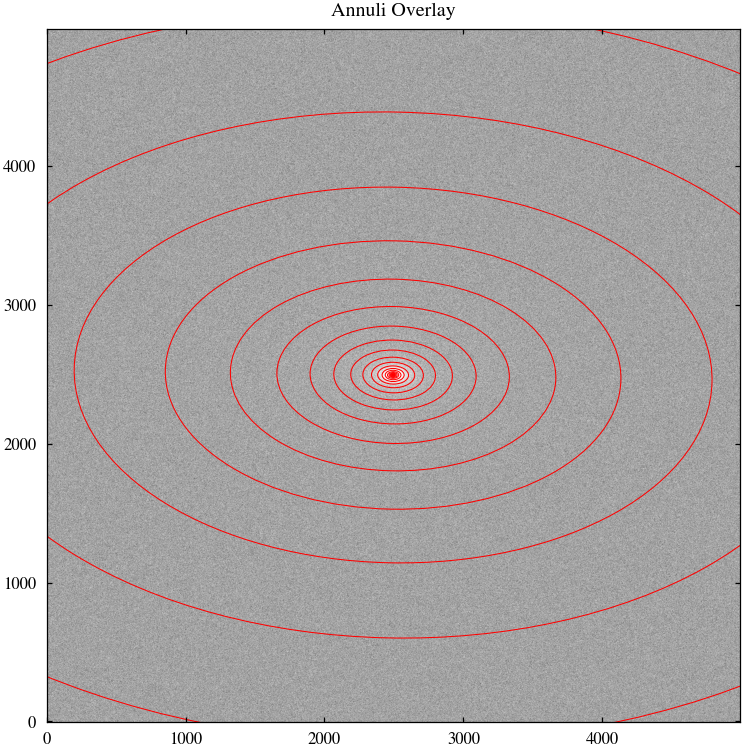

/tmp/ipykernel_1022117/4203603689.py:209: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


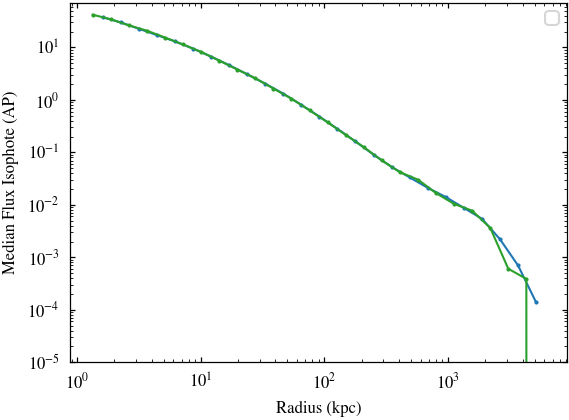

In [47]:
cluster_ids = ["cluster"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=False,
    SB_extraction=True,
    run_autoprof_function = False # if .prof files already exist and only SB extraction is needed.
)

# Example run for a real cluster image with existing mask files

Processing /home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku/EUC_NIR_W-STK_H-1eRASS J041723.0-474844.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
Using existing masks — skipping mask generation.

Processing Image: EUC_NIR_W-STK_H-1eRASS J041723.0-474844.fits
Number of NaN values: 242142
Replacing NaNs with 99.
Saved cleaned image to: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J041723.0-474844/autoprof_results/cleaned_1eRASS J041723.0-474844_H.fits
Extracting SB profile for 1eRASS J041723.0-474844 in H...
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


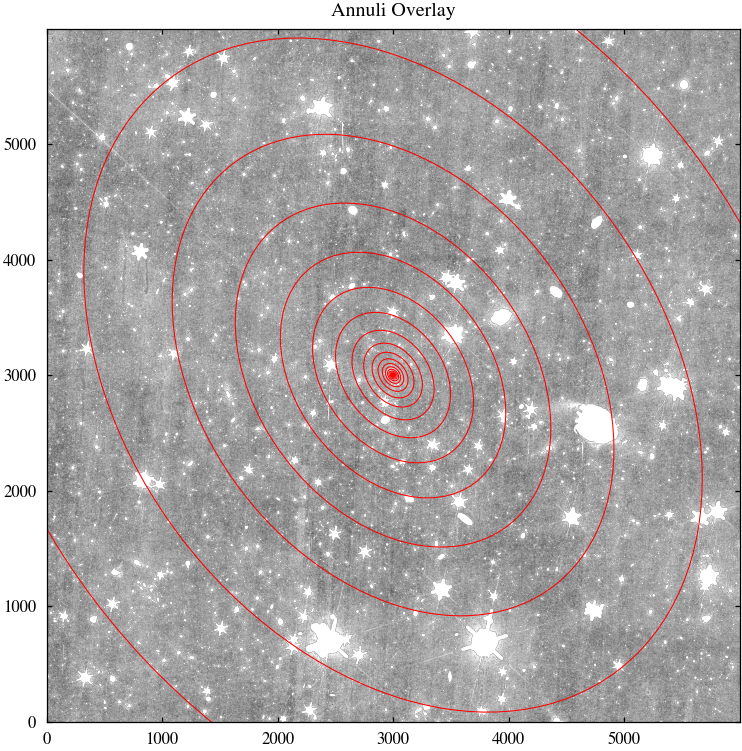

/tmp/ipykernel_1022117/4203603689.py:209: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


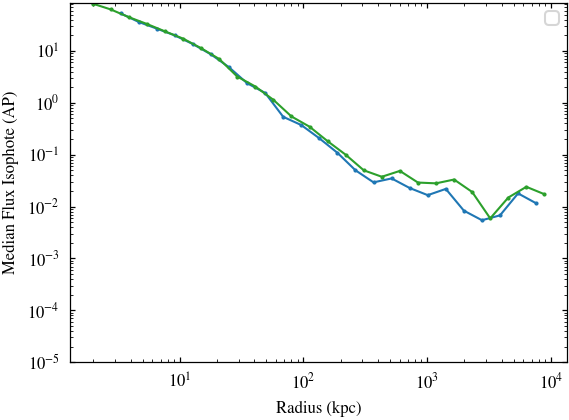

In [48]:
Erass_table = pd.read_csv('/home/ppztk1/Erosita/erosita_2E14_paper.csv')

cluster_ids = ["1eRASS J041723.0-474844"]

image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku")
outdir = Path('/home/ppztk1/Erosita/Outputs_Clusters/')

filters = ["H"] # can include other bands

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    cluster_info_table=Erass_table,
    mock_image=False,
    masking=True,
    rerun_masking=False,
    SB_extraction=True, # set True if masking files wants to be generated or re generated
    run_autoprof_function = False # if .prof files already exist and only SB extraction is needed.
)

PosixPath('/home/ppztk1/f_H.prof')

In [ ]:

# df1 =  pd.read_csv(outdir/cluster_id/f"Profile_measurements_no_noise.csv")
# df2 =  pd.read_csv(outdir/cluster_id/f"Profile_measurements.csv")
# prof1 =  pd.read_csv(outdir/cluster_id/"autoprof_results"/f"Mock_1_H_no_noise.prof", skiprows=1)
# prof2 =  pd.read_csv(outdir/cluster_id/"autoprof_results"/f"Mock_1_H.prof",skiprows=1)
# prof1['R'] = prof1['R'] / 0.3
# prof2['R'] = prof2['R'] / 0.3

# fig, ax = plt.subplots(1,1)
# plot_sb_profile(df1, 'Radial_Bin_Centre_pix', 'Clipped_median_flux_annulus', x_unit='kpc', redshift=cluster_z, label='Median Flux Annuli (No Noise)', markersize=2, ax=ax)
# plot_sb_profile(df2, 'Radial_Bin_Centre_pix', 'Clipped_median_flux_annulus',  x_unit='kpc', redshift=cluster_z, label='Median Flux Annuli (Fluctuations)', ax=ax, markersize=2, color='tab:orange')
# plot_sb_profile(prof1, x_column = 'R',  y_column='I', x_unit='kpc', redshift=cluster_z,  label='Median Flux Isophote (AP, no noise)', ax=ax,color='teal', markersize=2)
# plot_sb_profile(prof2, x_column = 'R',  y_column='I', x_unit='kpc', redshift=cluster_z, y_label=r'Surface Brightness ($\rm flux \ arcsec^{-2}$)', label='Median Flux Isophote (AP, fluctuations)', ax=ax,color='hotpink', markersize=2)


In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(9,4))

# ax[0].errorbar(prof1.R, prof1.ellip, yerr= prof1.ellip_e,  fmt='o-', markerfacecolor='teal')
# ax[0].errorbar(prof2.R, prof2.ellip, yerr= prof2.ellip_e, fmt='o-', markerfacecolor='hotpink')

# ax[0].set_ylim(0.2,1)
# ax[0].set_xscale('log')

# ax[1].errorbar(prof1.R, prof1.pa, yerr= prof1.pa_e, fmt='o-', markerfacecolor='teal')
# ax[1].errorbar(prof2.R, prof2.pa, yerr= prof2.pa_e, fmt='o-', markerfacecolor='hotpink')

# ax[1].set_ylim(0,180)
# ax[1].set_xscale('log')

# # plt.savefig(outdir/cluster_id/f"PA_ellip_comparisons.pdf")